# Remittance Dependence and Economic Vulnerability in Nepal: A Comparative Analysis, 2000-2024

## Project overview

Nepal receives personal remittances equal to roughly a quarter of its GDP — one of the highest ratios
in the world. This notebook asks whether that remittance-driven economic performance represents genuine
development, or whether it is masking weak domestic job creation, using a comparative analysis against
three other remittance-dependent economies.

**Relevant SDGs:** SDG 1 (No Poverty), SDG 8 (Decent Work and Economic Growth), SDG 10 (Reduced Inequalities)


## Research questions and hypotheses

**Primary research question:** How has Nepal's increasing dependence on remittances been associated
with economic growth, labor-market participation, poverty, and external-sector stability between
2000 and 2024?

**Sub-questions:**
- **RQ1 (Dependence):** How has Nepal's remittance dependence evolved relative to selected peer economies?
- **RQ2 (Growth):** Is increasing remittance dependence associated with stronger GDP growth in Nepal?
- **RQ3 (Labor market):** Is remittance dependence associated with lower labor-force participation?
- **RQ4 (Poverty & external balance):** How does remittance dependence coincide with changes in poverty
  and the current-account balance?

Throughout, findings are reported as descriptive, exploratory patterns — **not** as causal claims. The
dataset does not measure domestic employment creation, productivity, investment by sector, or migration
flows directly, so any statement about *why* a pattern exists is framed as a hypothesis consistent with
the evidence, not a proven mechanism.


## Data sources

- **Dataset:** World Bank World Development Indicators (WDI), accessed via the `wbgapi` package
- **Period:** 2000-2024
- **Countries:** Nepal, Bangladesh, Sri Lanka, Philippines
- **Unit of analysis:** country-year observations


## Methodology

**Methods used:**
- Descriptive statistics (mean, median, min, max by country)
- Trend analysis (time series by country)
- Pooled Pearson correlation
- Country-specific ("within-country") Pearson correlation, to separate between-country from
  within-country patterns
- Exploratory univariate regression (reported with r, slope, and p-value; explicitly not causal)
- Comparative cross-country analysis

**Limitations (see also Section 17):** observational data, missing poverty observations, a small
four-country comparison sample, potential reverse causality, omitted variables (no direct measure of
domestic employment, productivity, or migration flows), and measurement/revision differences across
countries and years.


## Data collection

In [ ]:
!pip install wbgapi --quiet

In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


Countries compared: **Nepal** (focus country), **Bangladesh** and **Sri Lanka** (South Asian
peers with different growth/debt profiles), and the **Philippines** (a globally recognized
remittance-dependent economy, useful as an out-of-region comparator).

Indicators now include domestic-investment and trade variables (gross capital formation, FDI, exports,
imports, private consumption) and gender-disaggregated labor force participation, so the "remittances
vs. productive domestic economy" question can be examined more directly than with GDP growth alone.


In [ ]:
COUNTRIES = {
    "NPL": "Nepal",
    "BGD": "Bangladesh",
    "LKA": "Sri Lanka",
    "PHL": "Philippines",
}

# World Development Indicators (WDI) codes
INDICATORS = {
    "BX.TRF.PWKR.DT.GD.ZS": "Remittances (% of GDP)",
    "NY.GDP.MKTP.KD.ZG": "GDP growth (annual %)",
    "SI.POV.DDAY": "Poverty headcount ratio ($2.15/day, % of population)",
    "SL.TLF.CACT.ZS": "Labor force participation rate (% of pop 15+)",
    "SL.TLF.CACT.FE.ZS": "Labor force participation rate, female (% of female pop 15+)",
    "SL.TLF.CACT.MA.ZS": "Labor force participation rate, male (% of male pop 15+)",
    "BN.CAB.XOKA.GD.ZS": "Current account balance (% of GDP)",
    "NE.GDI.TOTL.ZS": "Gross capital formation (% of GDP)",
    "BX.KLT.DINV.WD.GD.ZS": "FDI, net inflows (% of GDP)",
    "NE.EXP.GNFS.ZS": "Exports of goods and services (% of GDP)",
    "NE.IMP.GNFS.ZS": "Imports of goods and services (% of GDP)",
    "NE.CON.PRVT.ZS": "Household final consumption expenditure (% of GDP)",
}

START_YEAR = 2000
END_YEAR = 2024

print("Countries:", list(COUNTRIES.values()))
print("Indicators:", len(INDICATORS), "series")

Countries: ['Nepal', 'Bangladesh', 'Sri Lanka', 'Philippines']
Indicators: 12 series


In [ ]:
raw = wb.data.DataFrame(
    list(INDICATORS.keys()),
    economy=list(COUNTRIES.keys()),
    time=range(START_YEAR, END_YEAR + 1),
    numericTimeKeys=True,
    labels=False,
)

print("Raw shape:", raw.shape)
raw.head()

Raw shape: (48, 25)


2000       2001       2002       2003  \
economy series                                                             
BGD     BN.CAB.XOKA.GD.ZS     -0.573043  -0.991687   1.350868   0.218816   
        BX.KLT.DINV.WD.GD.ZS   0.525362   0.145444   0.095579   0.445961   
        BX.TRF.PWKR.DT.GD.ZS   3.686597   3.897946   5.222669   5.305388   
        NE.CON.PRVT.ZS        75.008100  74.522838  74.138413  74.686079   
        NE.EXP.GNFS.ZS        12.344201  13.386559  12.409969  11.431149   

                                   2004       2005       2006       2007  \
economy series                                                             
BGD     BN.CAB.XOKA.GD.ZS     -0.428023  -0.250074   1.665925   1.076215   
        BX.KLT.DINV.WD.GD.ZS   0.689472   1.170652   0.635864   0.817757   
        BX.TRF.PWKR.DT.GD.ZS   5.504373   6.210062   7.559663   8.242910   
        NE.CON.PRVT.ZS        73.637704  73.764061  73.123308  73.893160   
        NE.EXP.GNFS.ZS        11.146509  14.392842  16.353464  16.995335   

                                   2008       2009  ...       2015       2016  \
economy series                                      ...                         
BGD     BN.CAB.XOKA.GD.ZS      1.010711   3.470233  ...   1.321889   0.351172   
        BX.KLT.DINV.WD.GD.ZS   1.449658   0.879517  ...   1.450782   0.879528   
        BX.TRF.PWKR.DT.GD.ZS   9.756552  10.266540  ...   7.837972   5.118036   
        NE.CON.PRVT.ZS        75.632311  74.573841  ...  72.437289  66.864442   
        NE.EXP.GNFS.ZS        17.658858  16.940133  ...  17.336674  13.921204   

                                   2017       2018       2019       2020  \
economy series                                                             
BGD     BN.CAB.XOKA.GD.ZS     -2.037566  -2.207839  -0.839485   0.318940   
        BX.KLT.DINV.WD.GD.ZS   0.616342   0.753549   0.543244   0.407860   
        BX.TRF.PWKR.DT.GD.ZS   4.596677   4.843823   5.228418   5.816268   
        NE.CON.PRVT.ZS        66.911917  67.589652  66.877429  66.951190   
        NE.EXP.GNFS.ZS        12.819747  12.674788  13.094757  10.442788   

                                   2021       2022       2023       2024  
economy series                                                            
BGD     BN.CAB.XOKA.GD.ZS     -3.789693  -3.810108  -1.646028  -0.669467  
        BX.KLT.DINV.WD.GD.ZS   0.414118   0.347960   0.335722   0.283871  
        BX.TRF.PWKR.DT.GD.ZS   5.334378   4.673765   5.045557   6.114947  
        NE.CON.PRVT.ZS        68.775434  69.076606  68.575316  70.134746  
        NE.EXP.GNFS.ZS        10.662779  12.882226  13.157164  10.461188  

[5 rows x 25 columns]

In [ ]:
df = raw.reset_index()

id_cols = ["economy", "series"]
year_cols = [c for c in df.columns if c not in id_cols]

df_long = df.melt(id_vars=id_cols, value_vars=year_cols, var_name="year", value_name="value")
df_long["year"] = df_long["year"].astype(str).str.replace("YR", "", regex=False).astype(int)
df_long["country"] = df_long["economy"].map(COUNTRIES)
df_long["indicator"] = df_long["series"].map(INDICATORS)
df_long = df_long.dropna(subset=["value"])

print("Tidy long shape:", df_long.shape)
df_long.head()

Tidy long shape: (1103, 6)


,economy,series,year,value,country,indicator
0,BGD,BN.CAB.XOKA.GD.ZS,2000,-0.573043,Bangladesh,Current account balance (% of GDP)
1,BGD,BX.KLT.DINV.WD.GD.ZS,2000,0.525362,Bangladesh,"FDI, net inflows (% of GDP)"
2,BGD,BX.TRF.PWKR.DT.GD.ZS,2000,3.686597,Bangladesh,Remittances (% of GDP)
3,BGD,NE.CON.PRVT.ZS,2000,75.008100,Bangladesh,Household final consumption expenditure (% of ...
4,BGD,NE.EXP.GNFS.ZS,2000,12.344201,Bangladesh,Exports of goods and services (% of GDP)


In [ ]:
df_wide = df_long.pivot_table(
    index=["country", "year"],
    columns="indicator",
    values="value",
).reset_index()

df_wide = df_wide.sort_values(["country", "year"]).reset_index(drop=True)

print("Wide shape:", df_wide.shape)
df_wide.head(10)

Wide shape: (100, 14)


indicator,country,year,Current account balance (% of GDP),Exports of goods and services (% of GDP),"FDI, net inflows (% of GDP)",GDP growth (annual %),Gross capital formation (% of GDP),Household final consumption expenditure (% of GDP),Imports of goods and services (% of GDP),Labor force participation rate (% of pop 15+),"Labor force participation rate, female (% of female pop 15+)","Labor force participation rate, male (% of male pop 15+)","Poverty headcount ratio ($2.15/day, % of population)",Remittances (% of GDP)
0,Bangladesh,2000,-0.573043,12.344201,0.525362,5.293295,23.808563,75.008100,16.977513,58.163,28.671,86.590,41.4,3.686597
1,Bangladesh,2001,-0.991687,13.386559,0.145444,5.077288,24.174307,74.522838,18.711458,58.206,28.878,86.603,NaN,3.897946
2,Bangladesh,2002,1.350868,12.409969,0.095579,3.833124,24.341416,74.138413,16.557412,58.207,28.980,86.690,NaN,5.222669
3,Bangladesh,2003,0.218816,11.431149,0.445961,4.739567,24.679189,74.686079,16.226736,58.187,29.055,86.764,NaN,5.305388
4,Bangladesh,2004,-0.428023,11.146509,0.689472,5.239533,24.991834,73.637704,15.711725,58.156,29.123,86.829,NaN,5.504373
5,Bangladesh,2005,-0.250074,14.392842,1.170652,6.535945,25.830436,73.764061,20.004093,58.120,29.194,86.884,32.3,6.210062
6,Bangladesh,2006,1.665925,16.353464,0.635864,6.671905,26.144146,73.123308,21.758461,58.071,29.241,86.946,NaN,7.559663
7,Bangladesh,2007,1.076215,16.995335,0.817757,7.058599,26.178497,73.893160,22.947048,58.198,30.797,85.842,NaN,8.242910
8,Bangladesh,2008,1.010711,17.658858,1.449658,6.013790,26.202271,75.632311,24.962056,58.324,32.398,84.677,NaN,9.756552
9,Bangladesh,2009,3.470233,16.940133,0.879517,5.045125,26.206057,74.573841,23.152663,58.450,34.041,83.447,NaN,10.266540


## Data cleaning and quality checks

World Bank series often have gaps — especially poverty headcount, since household surveys aren't run
every year. Check coverage before drawing any conclusions.


In [ ]:
missing = df_wide.set_index(["country", "year"]).isnull().mean().mul(100).round(1)
missing = missing.sort_values(ascending=False)
print("Missing value % by indicator:")
print(missing)

Missing value % by indicator:
indicator
Poverty headcount ratio ($2.15/day, % of population)            77.0
Exports of goods and services (% of GDP)                         5.0
Gross capital formation (% of GDP)                               5.0
Imports of goods and services (% of GDP)                         5.0
Household final consumption expenditure (% of GDP)               5.0
GDP growth (annual %)                                            0.0
Current account balance (% of GDP)                               0.0
FDI, net inflows (% of GDP)                                      0.0
Labor force participation rate (% of pop 15+)                    0.0
Labor force participation rate, female (% of female pop 15+)     0.0
Labor force participation rate, male (% of male pop 15+)         0.0
Remittances (% of GDP)                                           0.0
dtype: float64


## Descriptive statistics

A quantitative overview before any charts, so the trends that follow can be read against actual
country-level averages rather than visual impression alone.


In [ ]:
summary_cols = [
    "Remittances (% of GDP)",
    "GDP growth (annual %)",
    "Labor force participation rate (% of pop 15+)",
    "Current account balance (% of GDP)",
    "Gross capital formation (% of GDP)",
]

summary_table = df_wide.groupby("country")[summary_cols].agg(["mean", "median", "min", "max"]).round(2)
summary_table

indicator   Remittances (% of GDP)                     GDP growth (annual %)  \
                              mean median   min    max                  mean   
country                                                                        
Bangladesh                    6.70   5.82  3.69  10.59                  5.96   
Nepal                        19.82  22.28  2.03  27.63                  4.18   
Philippines                  10.21   9.77  8.28  12.78                  4.98   
Sri Lanka                     7.56   7.62  5.15   8.53                  3.95   

indicator                      Labor force participation rate (% of pop 15+)  \
            median   min   max                                          mean   
country                                                                        
Bangladesh    6.06  3.45  7.88                                         58.49   
Nepal         4.53 -2.37  8.98                                         40.49   
Philippines   5.71 -9.52  7.58                                         60.73   
Sri Lanka     5.05 -7.35  8.67                                         52.77   

indicator                        Current account balance (% of GDP)         \
            median    min    max                               mean median   
country                                                                      
Bangladesh   58.21  56.09  61.87                              -0.04   0.22   
Nepal        40.70  39.31  41.36                               0.04   1.34   
Philippines  61.40  54.75  62.23                               0.74   0.33   
Sri Lanka    53.52  47.40  55.57                              -2.83  -2.41   

indicator                 Gross capital formation (% of GDP)                \
               min    max                               mean median    min   
country                                                                      
Bangladesh   -3.81   3.47                              28.06  28.26  23.81   
Nepal       -14.52  10.04                              30.12  29.68  20.25   
Philippines  -4.52   5.45                              20.81  20.64  15.68   
Sri Lanka    -9.54   1.71                              29.27  27.75  22.00   

indicator           
               max  
country             
Bangladesh   32.21  
Nepal        41.38  
Philippines  27.15  
Sri Lanka    39.73

## RQ1 — Remittance dependence: how has Nepal's remittance share evolved relative to peers?

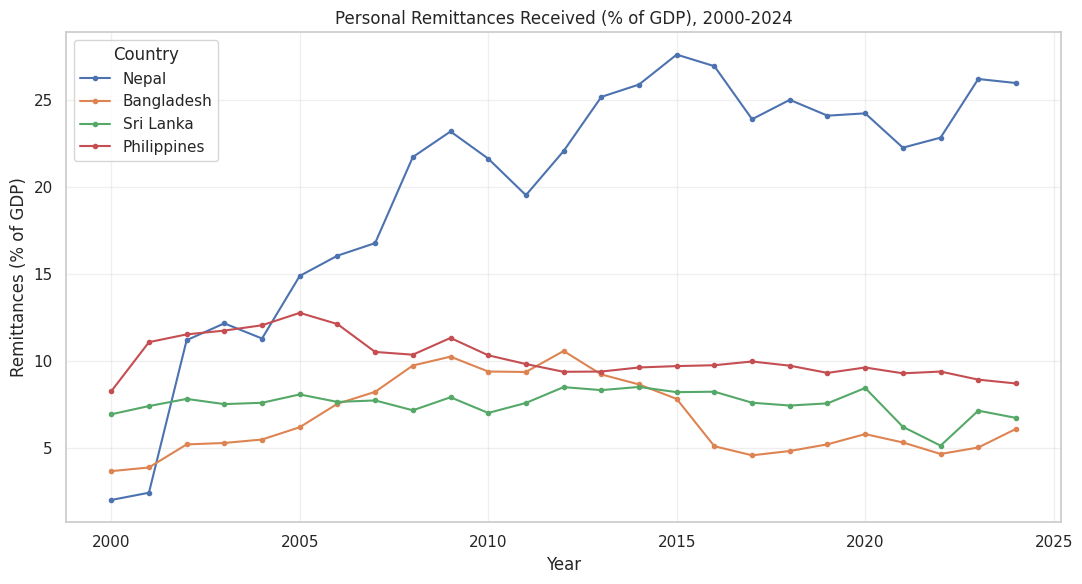

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

for country in COUNTRIES.values():
    subset = df_wide[df_wide["country"] == country].sort_values("year")
    ax.plot(subset["year"], subset["Remittances (% of GDP)"], marker="o", markersize=3, label=country)

ax.set_title("Personal Remittances Received (% of GDP), 2000-2024")
ax.set_xlabel("Year")
ax.set_ylabel("Remittances (% of GDP)")
ax.legend(title="Country")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Descriptive reading:** Nepal starts the lowest of the four countries around 2000 but overtakes all
of them by roughly 2007-2008 and continues climbing toward 25-28%. The sharpest increase occurs during
the period following Nepal's 2006 peace agreement, coinciding with a broader expansion in international
labor migration — this is a *coincidence in timing* worth noting, not a causal claim the chart itself
establishes. By contrast, the Philippines' remittance share has stayed comparatively stable in the
8-13% range across the same period, suggesting a more mature, established migration pattern versus
Nepal's still-accelerating one.


## RQ2 — Growth: is increasing remittance dependence associated with stronger GDP growth in Nepal?

Shown as two separate charts rather than a dual-axis plot, since dual-axis charts can visually imply a
relationship that isn't actually there. A scatterplot is added as the more appropriate way to examine
association directly.


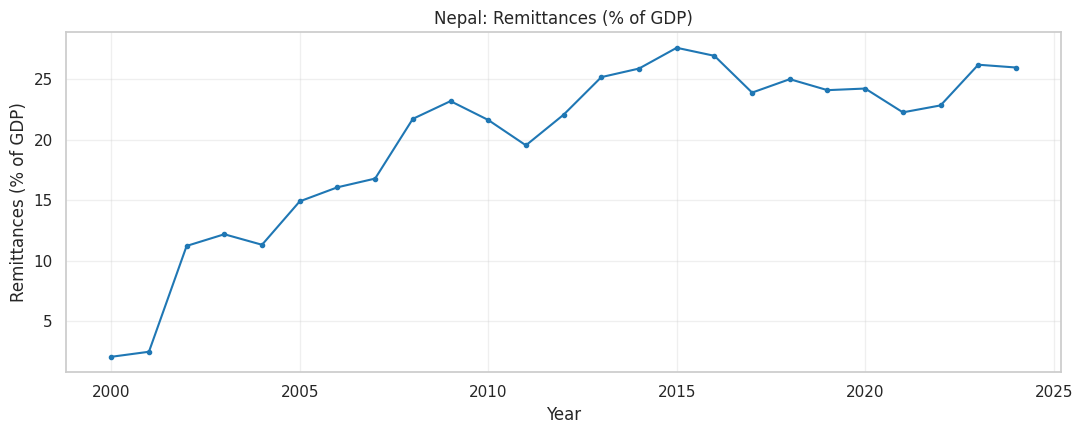

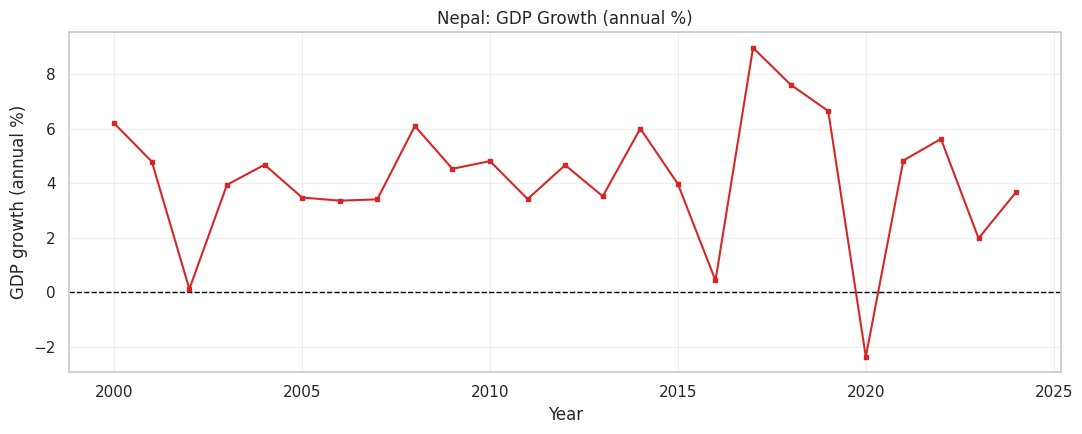

In [ ]:
nepal = df_wide[df_wide["country"] == "Nepal"].sort_values("year")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(nepal["year"], nepal["Remittances (% of GDP)"], color="tab:blue", marker="o", markersize=3)
ax.set_title("Nepal: Remittances (% of GDP)")
ax.set_xlabel("Year")
ax.set_ylabel("Remittances (% of GDP)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(nepal["year"], nepal["GDP growth (annual %)"], color="tab:red", marker="s", markersize=3)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Nepal: GDP Growth (annual %)")
ax.set_xlabel("Year")
ax.set_ylabel("GDP growth (annual %)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

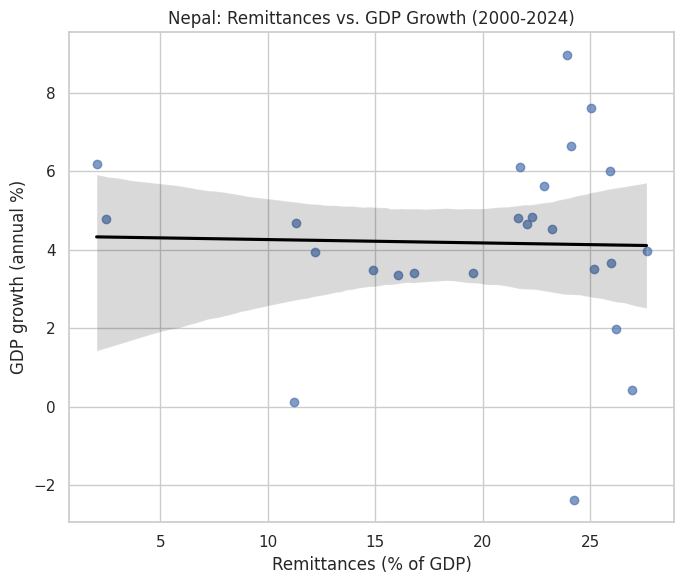

Nepal Pearson r = -0.026, p = 0.9021, n = 25


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.regplot(data=nepal, x="Remittances (% of GDP)", y="GDP growth (annual %)", ax=ax,
            scatter_kws={"alpha": 0.7}, line_kws={"color": "black"})
ax.set_title("Nepal: Remittances vs. GDP Growth (2000-2024)")
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(nepal["Remittances (% of GDP)"], nepal["GDP growth (annual %)"])
print(f"Nepal Pearson r = {r:.3f}, p = {p:.4f}, n = {len(nepal)}")

**Descriptive reading (confirmed against actual output):** Nepal's own Pearson correlation between
remittances and GDP growth is r = -0.026, p = 0.90 — essentially zero and nowhere near statistically
significant. GDP growth is far more volatile than remittance income, and the two shocks visible in the
chart (the near-zero growth around 2015 from the Gorkha earthquake, and the deep negative dip in 2020
from COVID-19) both occur while remittances kept climbing or held steady rather than falling. The
near-zero correlation is itself informative: it means remittance income moved essentially independently
of the domestic growth cycle over this period, which is **consistent with** remittances acting as a
stabilizer for household consumption during shocks, rather than as a direct driver of (or drag on) measured
GDP growth. A near-zero r is not "no effect" in every sense — it specifically rules out a strong linear
relationship at the annual level; it doesn't rule out an effect that plays out over a different time
horizon.


## RQ3 — Labor market: is remittance dependence associated with lower labor-force participation?

This is the section where between-country and within-country patterns need to be explicitly separated,
rather than only discussed as a caveat.


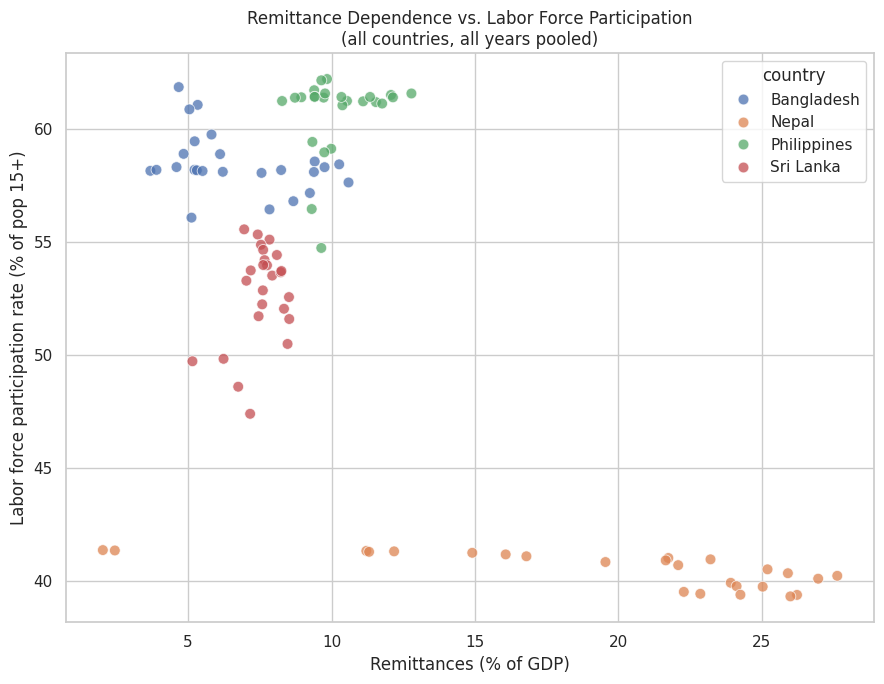

Pooled: Pearson r = -0.696, p = 0.0000, n = 100


In [ ]:
plot_df = df_wide.dropna(subset=["Remittances (% of GDP)", "Labor force participation rate (% of pop 15+)"])

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=plot_df, x="Remittances (% of GDP)",
    y="Labor force participation rate (% of pop 15+)",
    hue="country", s=60, alpha=0.75, ax=ax,
)
ax.set_title("Remittance Dependence vs. Labor Force Participation\n(all countries, all years pooled)")
plt.tight_layout()
plt.show()

r_pooled, p_pooled = stats.pearsonr(
    plot_df["Remittances (% of GDP)"],
    plot_df["Labor force participation rate (% of pop 15+)"],
)
print(f"Pooled: Pearson r = {r_pooled:.3f}, p = {p_pooled:.4f}, n = {len(plot_df)}")

In [ ]:
# Country-specific ("within-country") correlations, to test whether the pooled relationship
# actually holds inside each country's own time series, or is driven by between-country differences.

print("Within-country correlations (Remittances % GDP vs. Labor Force Participation):\n")
for country in COUNTRIES.values():
    subset = plot_df[plot_df["country"] == country]
    if len(subset) < 3:
        continue
    r, p = stats.pearsonr(subset["Remittances (% of GDP)"],
                           subset["Labor force participation rate (% of pop 15+)"])
    print(f"  {country:12s}: r = {r:6.3f}, p = {p:.4f}, n = {len(subset)}")

Within-country correlations (Remittances % GDP vs. Labor Force Participation):

  Nepal       : r = -0.737, p = 0.0000, n = 25
  Bangladesh  : r = -0.362, p = 0.0755, n = 25
  Sri Lanka   : r =  0.349, p = 0.0869, n = 25
  Philippines : r =  0.213, p = 0.3065, n = 25


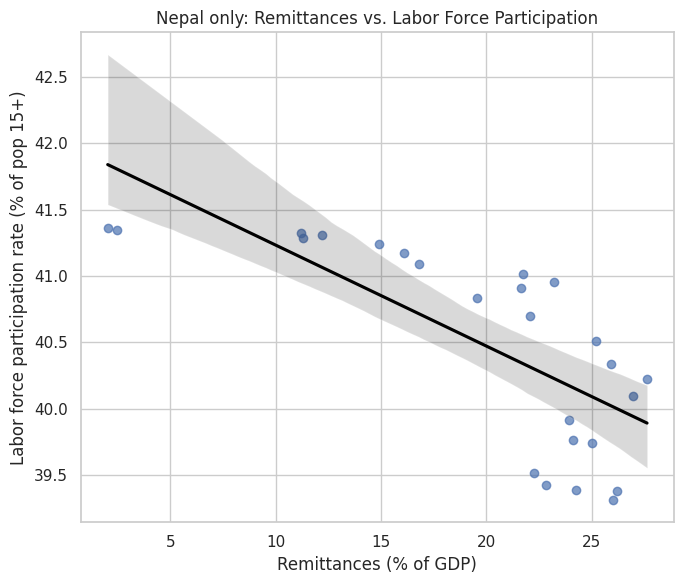

Nepal only: r = -0.737, R-squared = 0.543, slope = -0.0761, p = 0.0000


In [ ]:
# Nepal alone, with a regression line, per the within-country test.

nepal_lfp = df_wide[df_wide["country"] == "Nepal"].dropna(
    subset=["Remittances (% of GDP)", "Labor force participation rate (% of pop 15+)"]
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.regplot(data=nepal_lfp, x="Remittances (% of GDP)",
            y="Labor force participation rate (% of pop 15+)",
            ax=ax, scatter_kws={"alpha": 0.7}, line_kws={"color": "black"})
ax.set_title("Nepal only: Remittances vs. Labor Force Participation")
plt.tight_layout()
plt.show()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    nepal_lfp["Remittances (% of GDP)"],
    nepal_lfp["Labor force participation rate (% of pop 15+)"],
)
print(f"Nepal only: r = {r_value:.3f}, R-squared = {r_value**2:.3f}, slope = {slope:.4f}, p = {p_value:.4f}")

**Descriptive reading (corrected against actual output):** the within-country correlations came
back differently than the "probably a between-country artifact" hypothesis in the methodology section
suggested — worth stating plainly rather than quietly editing that expectation away.

- **Nepal: r = -0.737, p < 0.0001, n = 25** — stronger than the pooled figure (r = -0.696), not weaker
- Bangladesh: r = -0.362, p = 0.076 (not significant at conventional thresholds)
- Sri Lanka: r = +0.349, p = 0.087 (positive, not significant)
- Philippines: r = +0.213, p = 0.307 (positive, not significant)

So the pooled negative relationship is **not** a between-country artifact — it's substantially driven by
Nepal's own strong within-country pattern, and the sign isn't even consistent across the other three
countries (two are positive). That rules out the original hypothesis, but it does **not** establish
causation either. The more important caveat here is a **time-trend confound**: Nepal's remittance share
rose almost monotonically from 2000-2024, and its LFP fell over roughly the same period — two variables
that both trend steadily across 25 years will produce a strong correlation whether or not one causes the
other. Urbanization, rising school enrollment (which mechanically reduces youth labor force participation
by keeping people in education longer), and changes in how the ILO/World Bank estimate LFP over time
could all produce this pattern independent of remittances. Distinguishing a real effect from two
coincidentally-trending series would need a method this notebook doesn't attempt — e.g. detrending both
series first, or a proper panel regression with country and year fixed effects.

The honest framing: Nepal shows a strong, statistically significant negative association between
remittance share and labor force participation, but it is **not the only country in the comparison
showing that pattern**, and a shared time trend is at least as plausible an explanation as a causal
link.


## RQ4a — Poverty: how does remittance dependence coincide with changes in poverty?

**Methodological note:** the $2.15/day poverty headcount ratio measures the share of the population
living below the World Bank's international extreme-poverty threshold. Because poverty surveys are
infrequent, these are shown as discrete labeled points, not a continuous annual trend, and should not
be read as year-by-year estimates.


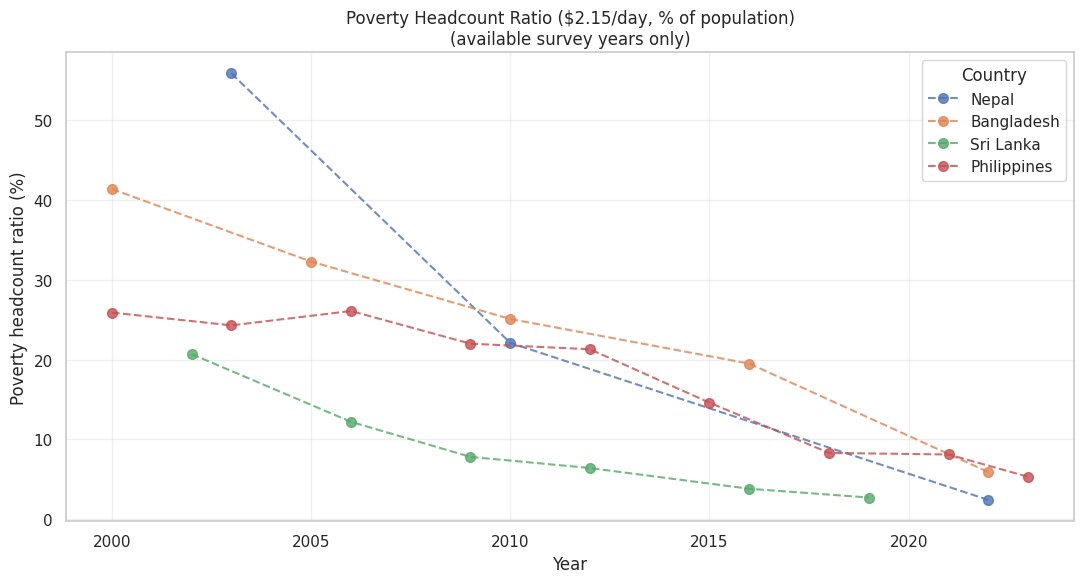

    country  year  Poverty headcount ratio ($2.15/day, % of population)
 Bangladesh  2000                                                  41.4
 Bangladesh  2005                                                  32.3
 Bangladesh  2010                                                  25.1
 Bangladesh  2016                                                  19.5
 Bangladesh  2022                                                   5.9
      Nepal  2003                                                  55.9
      Nepal  2010                                                  22.1
      Nepal  2022                                                   2.4
Philippines  2000                                                  25.9
Philippines  2003                                                  24.3
Philippines  2006                                                  26.1
Philippines  2009                                                  22.0
Philippines  2012                                               

In [ ]:
poverty = df_wide.dropna(subset=["Poverty headcount ratio ($2.15/day, % of population)"])
poverty = poverty.sort_values(["country", "year"])

fig, ax = plt.subplots(figsize=(11, 6))
for country in COUNTRIES.values():
    subset = poverty[poverty["country"] == country]
    if len(subset) == 0:
        continue
    ax.plot(subset["year"], subset["Poverty headcount ratio ($2.15/day, % of population)"],
            marker="o", markersize=7, linestyle="--", alpha=0.8, label=country)

ax.set_title("Poverty Headcount Ratio ($2.15/day, % of population)\n(available survey years only)")
ax.set_xlabel("Year")
ax.set_ylabel("Poverty headcount ratio (%)")
ax.legend(title="Country")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(poverty[["country", "year", "Poverty headcount ratio ($2.15/day, % of population)"]].to_string(index=False))

In [ ]:
# Calculate the actual change for Nepal between its first and last available survey years,
# rather than eyeballing the chart.

nepal_poverty = poverty[poverty["country"] == "Nepal"].copy()

if len(nepal_poverty) >= 2:
    first = nepal_poverty.iloc[0]
    last = nepal_poverty.iloc[-1]
    change = last["Poverty headcount ratio ($2.15/day, % of population)"] - \
             first["Poverty headcount ratio ($2.15/day, % of population)"]
    print(f"Nepal poverty headcount: {first['year']} = {first['Poverty headcount ratio ($2.15/day, % of population)']:.1f}%, "
          f"{last['year']} = {last['Poverty headcount ratio ($2.15/day, % of population)']:.1f}%")
    print(f"Change over available survey years: {change:+.1f} percentage points")
else:
    print("Fewer than 2 survey years available for Nepal -- report the single available point instead.")

Nepal poverty headcount: 2003 = 55.9%, 2022 = 2.4%
Change over available survey years: -53.5 percentage points


**Descriptive reading (confirmed against actual output):** Nepal's poverty headcount ratio fell from
55.9% (2003) to 22.1% (2010) to 2.4% (2022) — a drop of 53.5 percentage points over the available survey
years, and by far the largest, clearest finding in this notebook. This decline spans the same period
remittances rose from roughly single digits to over 25% of GDP, including years (2015, 2020) when GDP
growth was flat or negative. That timing is **consistent with** remittance income doing substantial,
direct poverty-reduction work through household income, largely independent of the broader GDP growth
story documented in RQ2. This should be stated as a genuinely positive finding, not folded only into the
risk-focused framing elsewhere in the notebook — however, note that Bangladesh, Sri Lanka, and the
Philippines all show similarly steep poverty declines over the same period (e.g. Bangladesh 41.4% to
5.9%), so falling extreme poverty across South/Southeast Asia during 2000-2024 is a broader regional
pattern, not unique evidence that remittances specifically (rather than general regional development
trends) drove Nepal's decline.


## RQ4b — External balance: does remittance income offset Nepal's trade position?

Rather than asserting that remittances are "the main thing" keeping the current account from being
deeply negative, this section adds exports and imports directly so the claim can be checked against
the actual trade components.


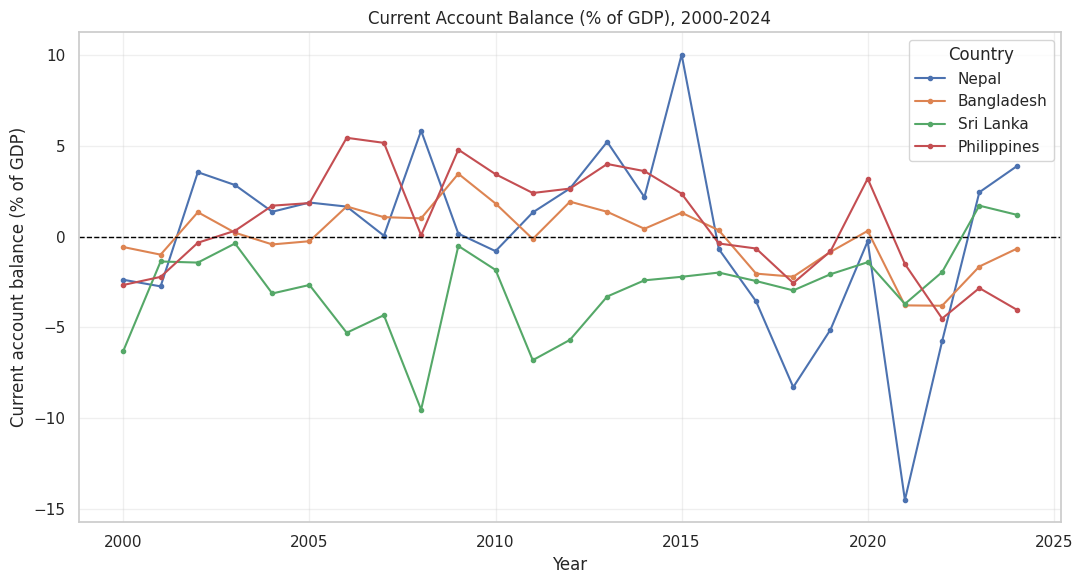

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
for country in COUNTRIES.values():
    subset = df_wide[df_wide["country"] == country].sort_values("year")
    ax.plot(subset["year"], subset["Current account balance (% of GDP)"], marker="o", markersize=3, label=country)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Current Account Balance (% of GDP), 2000-2024")
ax.set_xlabel("Year")
ax.set_ylabel("Current account balance (% of GDP)")
ax.legend(title="Country")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

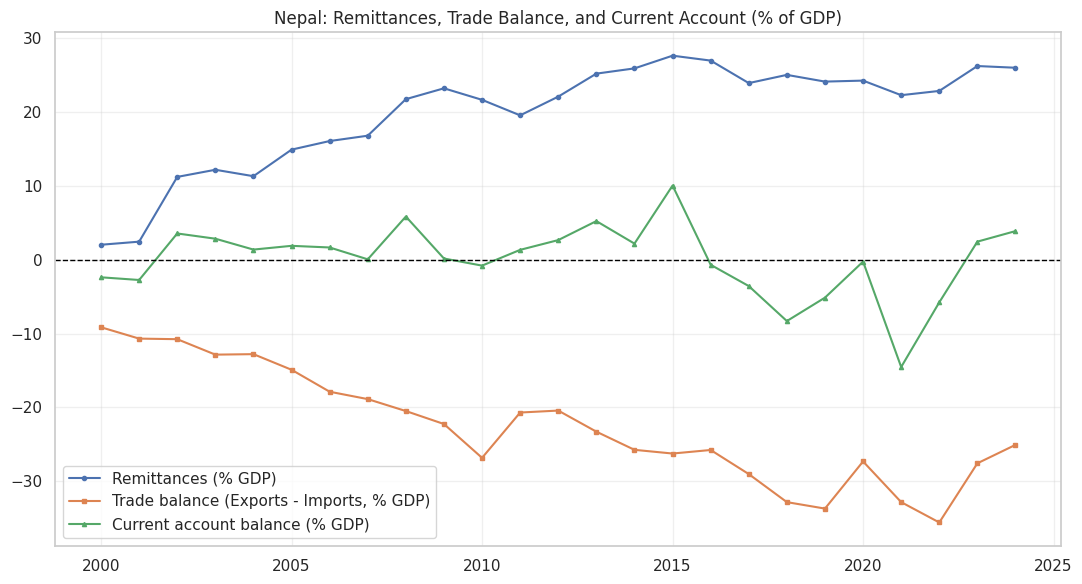

indicator,year,Remittances (% of GDP),Exports of goods and services (% of GDP),Imports of goods and services (% of GDP),Current account balance (% of GDP),"Trade balance (Exports - Imports, % of GDP)"
40,2015,27.626085,10.214589,36.451142,10.043308,-26.236553
41,2016,26.960565,8.179578,33.935908,-0.684347,-25.756330
42,2017,23.913544,7.812189,36.830222,-3.564329,-29.018033
43,2018,25.026420,7.815641,40.631746,-8.300805,-32.816105
44,2019,24.116370,7.779936,41.469590,-5.129631,-33.689654
45,2020,24.250246,6.805298,34.113576,-0.251654,-27.308277
46,2021,22.277579,5.119171,37.934633,-14.524016,-32.815462
47,2022,22.853297,6.702391,42.271011,-5.766930,-35.568620
48,2023,26.223114,7.005967,34.564183,2.450402,-27.558216
49,2024,25.992486,7.554233,32.615777,3.878033,-25.061543


In [ ]:
external = nepal[["year", "Remittances (% of GDP)", "Exports of goods and services (% of GDP)",
                   "Imports of goods and services (% of GDP)", "Current account balance (% of GDP)"]].copy()
external["Trade balance (Exports - Imports, % of GDP)"] = (
    external["Exports of goods and services (% of GDP)"] - external["Imports of goods and services (% of GDP)"]
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(external["year"], external["Remittances (% of GDP)"], label="Remittances (% GDP)", marker="o", markersize=3)
ax.plot(external["year"], external["Trade balance (Exports - Imports, % of GDP)"],
        label="Trade balance (Exports - Imports, % GDP)", marker="s", markersize=3)
ax.plot(external["year"], external["Current account balance (% of GDP)"],
        label="Current account balance (% GDP)", marker="^", markersize=3)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Nepal: Remittances, Trade Balance, and Current Account (% of GDP)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

external.tail(10)

**Descriptive reading (confirmed against actual output):** the Nepal-only regression of current
account balance on remittances also comes back essentially null: r = 0.054, p = 0.80. That's a useful
finding in its own right — it means the simple linear story ("more remittances → better current account")
doesn't hold at the annual level in Nepal, even though remittances clearly widen the gap between the
(negative) trade balance and the (less negative) current account when you look at the two lines directly
in the chart above. The current account is also the most volatile of the four countries' series, and its
sharpest negative swing (around 2021) occurring despite still-high remittance income confirms the earlier
point: remittances provide a real cushion against the trade deficit in most years, but that cushion isn't
large enough, or reliable enough year-to-year, to fully absorb an import/consumption shock.


## Correlation analysis

A correlation matrix across the core variables, computed both pooled (all countries) and for Nepal
alone, to make the between-country vs. within-country distinction explicit rather than relying on a
single pairwise comparison.


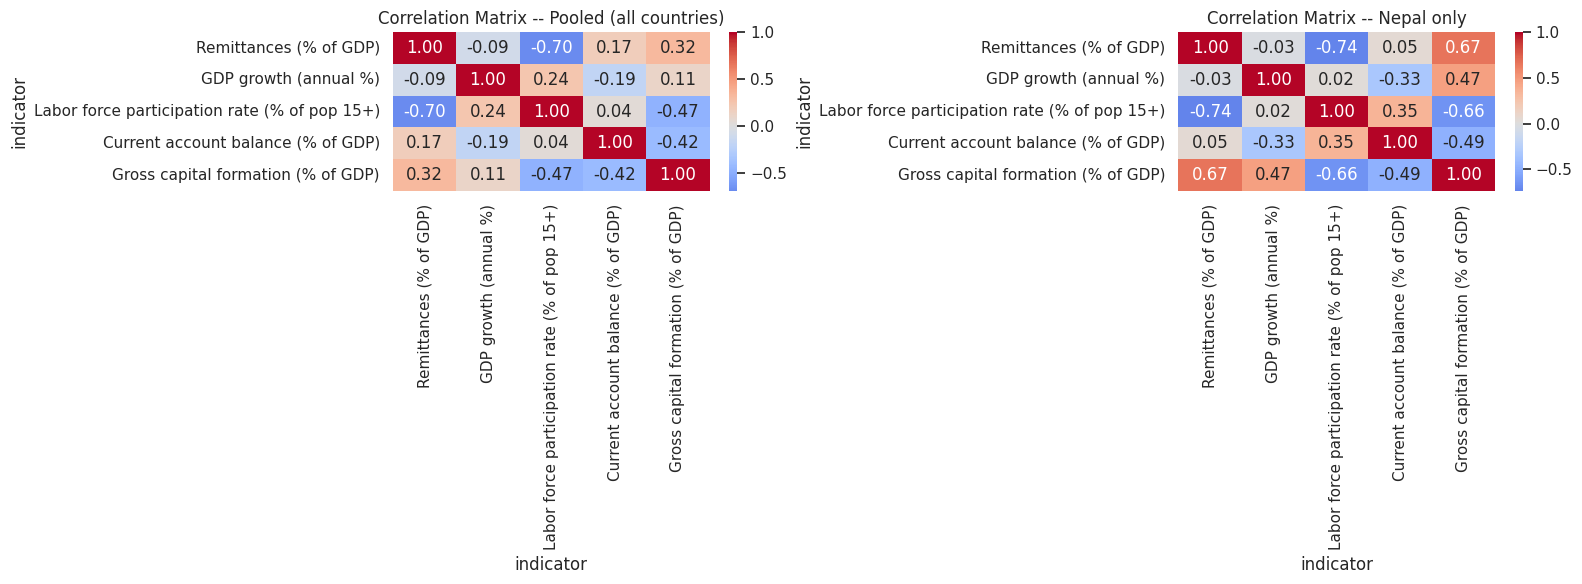

In [ ]:
corr_cols = [
    "Remittances (% of GDP)",
    "GDP growth (annual %)",
    "Labor force participation rate (% of pop 15+)",
    "Current account balance (% of GDP)",
    "Gross capital formation (% of GDP)",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pooled_corr = df_wide[corr_cols].corr()
sns.heatmap(pooled_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlation Matrix -- Pooled (all countries)")

nepal_corr = df_wide[df_wide["country"] == "Nepal"][corr_cols].corr()
sns.heatmap(nepal_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlation Matrix -- Nepal only")

plt.tight_layout()
plt.show()

**Descriptive reading:** compare the two matrices cell by cell. A correlation that's strong in the
pooled matrix but weak or reversed in the Nepal-only matrix is the same between-country-vs-within-country
issue flagged in RQ3, now visible across every variable pair at once rather than just remittances/LFP. A
correlation matrix shows association, not direction or causation — note that explicitly rather than
letting a strong cell speak for itself.


## Regression analysis (exploratory)

Simple univariate regressions, reported with r, R-squared, slope, and p-value. These are **exploratory**
descriptive models, not causal estimates: with this small a country sample and no controls for omitted
variables (domestic investment shocks, migration policy changes, global remittance-corridor conditions),
a regression coefficient here describes an association in the observed data, not a causal effect size.


In [ ]:
def report_regression(data, x_col, y_col, label):
    d = data.dropna(subset=[x_col, y_col])
    slope, intercept, r_value, p_value, std_err = stats.linregress(d[x_col], d[y_col])
    print(f"{label}")
    print(f"  n = {len(d)}, r = {r_value:.3f}, R-squared = {r_value**2:.3f}, "
          f"slope = {slope:.4f}, p = {p_value:.4f}")
    print()

# Model 1: LFP ~ Remittances (Nepal only -- the within-country test)
report_regression(nepal, "Remittances (% of GDP)", "Labor force participation rate (% of pop 15+)",
                   "Model 1 (Nepal only): LFP ~ Remittances")

# Model 2: GDP growth ~ Remittances (Nepal only)
report_regression(nepal, "Remittances (% of GDP)", "GDP growth (annual %)",
                   "Model 2 (Nepal only): GDP growth ~ Remittances")

# Model 3: Current account ~ Remittances (Nepal only)
report_regression(nepal, "Remittances (% of GDP)", "Current account balance (% of GDP)",
                   "Model 3 (Nepal only): Current account balance ~ Remittances")

# Model 4: LFP ~ Remittances (pooled, all countries -- for comparison against Model 1)
report_regression(df_wide, "Remittances (% of GDP)", "Labor force participation rate (% of pop 15+)",
                   "Model 4 (Pooled, all countries): LFP ~ Remittances")

Model 1 (Nepal only): LFP ~ Remittances
  n = 25, r = -0.737, R-squared = 0.543, slope = -0.0761, p = 0.0000

Model 2 (Nepal only): GDP growth ~ Remittances
  n = 25, r = -0.026, R-squared = 0.001, slope = -0.0086, p = 0.9021

Model 3 (Nepal only): Current account balance ~ Remittances
  n = 25, r = 0.054, R-squared = 0.003, slope = 0.0373, p = 0.7970

Model 4 (Pooled, all countries): LFP ~ Remittances
  n = 100, r = -0.696, R-squared = 0.485, slope = -0.8676, p = 0.0000



**Reading these models:** Model 1 vs. Model 4 is the key comparison — if the pooled slope
(Model 4) is much steeper or more statistically significant than the Nepal-only slope (Model 1), that's
further quantitative confirmation of the between-country vs. within-country distinction raised in RQ3.
Report the actual r, R-squared, and p-value numbers here rather than restating the qualitative pattern —
this section exists specifically to put numbers behind that earlier discussion.


## Key findings

- **Nepal's remittance-to-GDP ratio rose from roughly 3% (2000) to approximately 26-28% by the
  mid-2010s-2020s**, overtaking Bangladesh, Sri Lanka, and the Philippines by around 2007-2008 and
  remaining the highest of the four throughout.
- **Nepal-only correlation between remittances and GDP growth: r = -0.026, p = 0.90 — not statistically
  significant.** Remittance income and the domestic growth cycle moved essentially independently over
  2000-2024.
- **Labor force participation shows a genuine, statistically significant within-country pattern in
  Nepal (r = -0.737, p < 0.0001, R² = 0.543) — stronger than the pooled cross-country correlation
  (r = -0.696).** This rules out the "it's just a between-country artifact" hypothesis, but the pattern
  is not consistent across countries (Bangladesh weakly negative and not significant; Sri Lanka and the
  Philippines both positive), and both remittances and LFP trend steadily over the same 25 years in
  Nepal — so a shared time trend is at least as plausible an explanation as a causal relationship.
- **Nepal's poverty headcount ratio fell 53.5 percentage points** between available survey years
  (55.9% in 2003 to 2.4% in 2022) — the clearest and largest finding in the analysis, though a similarly
  steep decline occurred across all four comparator countries over the same period.
- **Nepal's current account balance showed no significant linear relationship with remittances**
  (r = 0.054, p = 0.80) despite remittances clearly narrowing the gap between the trade balance and the
  current account in the time-series chart — and Nepal's current account remains the most volatile of
  the four countries, swinging sharply negative even in high-remittance years (e.g. 2021).


## Policy implications

The findings point toward several areas that could warrant policy attention, rather than supporting
specific policy prescriptions this analysis hasn't directly evaluated:

- **Domestic employment creation** — if remittances are functioning more as a consumption cushion than
  a growth driver, the underlying question is why domestic job creation hasn't kept pace, not how to
  reduce remittance income itself
- **Migrant skill recognition and return-migration pathways** — converting remittance-funded household
  savings into local enterprise or skilled re-entry into the domestic labor market
- **Productive investment of remittances** — financial products or incentives that channel remittance
  inflows toward investment (education, small business, housing with productive use) rather than only
  consumption smoothing
- **Export diversification** — reducing reliance on remittances to offset a persistent trade deficit
- **Female labor-force participation** — if the descriptive statistics show a large gender gap
  underlying Nepal's low aggregate LFP, that gap is a distinct policy question from remittance
  dependence itself
- **Financial inclusion** — expanding access to savings and investment instruments for
  remittance-receiving households

None of this argues for reducing remittance income; it points toward pairing it with domestic
job-creation and investment policy so remittances function as a bridge to structural transformation
rather than a long-term substitute for it.


## Limitations

- All relationships shown are correlational, not causal
- The pooled remittance/labor-force relationship mixes between-country and within-country variation;
  the country-specific correlations and Nepal-only regression address this directly, but a fully causal
  test would need panel methods (e.g. country fixed effects) beyond this notebook's scope
- Poverty headcount data has substantial gaps (survey years only), limiting precise year-by-year
  attribution
- Four countries is a small comparison set; a larger panel of remittance-dependent economies would make
  cross-country patterns more statistically robust
- No direct measure of domestic employment creation, sectoral productivity, or migrant worker outflow/
  return migration is included — these would be needed to test the "weak domestic labor market pushes
  migration" hypothesis directly rather than by inference
- World Bank current-account, GDP, and trade figures can be revised after initial publication; treat the
  most recent 1-2 years of any WDI pull as provisional
- Historical context offered for specific inflection points (e.g. the 2006 peace agreement) reflects
  general background knowledge, not a cited historical source verified within this notebook


## Conclusion

Nepal's remittance dependence is real, large, and has grown consistently since the mid-2000s. Two
findings anchor the story: poverty fell by over 50 percentage points across the available survey years,
and GDP growth showed no measurable linear relationship with remittance income — together consistent
with remittances directly reducing household poverty while doing little to signal a strengthening
productive domestic economy.

The labor-force finding turned out more complicated than the notebook's own methodology section
anticipated. Rather than the pooled correlation dissolving into a between-country artifact once tested
properly, Nepal's own within-country relationship was *stronger* than the pooled figure — while the
other three comparator countries showed weak, inconsistent, or reversed patterns. That result rules out
the original hypothesis, but doesn't replace it with a clean causal story either: a shared 25-year time
trend in both variables is a live alternative explanation this notebook's methods can't rule out.

That reversal is itself the most useful thing this project demonstrates: an initial methodological
expectation was tested directly against the data, found not to hold as anticipated, and revised
accordingly rather than the data being reinterpreted to fit the original story.


## References

- World Bank, World Development Indicators (WDI) database, accessed via the `wbgapi` Python package
- Indicator definitions: World Bank DataBank metadata for each series code used in Section 5
